# Real-data pure-space regional nugget profile

This notebook tests whether the nugget behaves like a local/regional feature.

Workflow:

1. Split the original pure-space domain into a `4 x 4` grid of spatial tiles.
2. For each hour and smooth (`0.3`, `0.5`), fit a global pure-space isotropic Matérn model on the full domain.
3. Use the global fitted `sigmasq` and `range` as anchors.
4. Within each tile, fit **only the nugget** while holding `sigmasq` and `range` fixed.
5. Summarize the 16 regional nuggets by hour/smooth: distribution, mean, SD, and tile heatmaps.

This intentionally asks a local question: if nugget is mainly unresolved local variability or local measurement/representativeness error, its regional distribution should be informative even when a global stationary covariance is imperfect.


In [1]:
import gc
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

LOCAL_SRC = '/Users/joonwonlee/Documents/GEMS_TCO-1/src'
AMAREL_SRC = '/home/jl2815/tco'
SRC = AMAREL_SRC if Path(AMAREL_SRC).exists() else LOCAL_SRC
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from GEMS_TCO import configuration as config
from GEMS_TCO import orderings
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO.kernels_space_iso_050826 import HybridSpaceIsoTrendVecchiaFit

DEVICE = torch.device('cpu')
DTYPE = torch.float64
ROUND_DECIMALS = 4

def round_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out

class HybridSpaceIsoLatTrendVecchiaFit(HybridSpaceIsoTrendVecchiaFit):
    """Hybrid isotropic spatial Vecchia with intercept + centered latitude GLS mean."""

    def _init_mean_design(self, mean_design: str):
        if mean_design != 'lat':
            return super()._init_mean_design(mean_design)
        self.mean_design = 'lat'
        self.n_features = 2
        self.lon_mean_val = 0.0

    def _design_from_rows(self, rows: torch.Tensor) -> torch.Tensor:
        if getattr(self, 'mean_design', None) != 'lat':
            return super()._design_from_rows(rows)
        orig_shape = rows.shape[:-1]
        flat = rows.reshape(-1, rows.shape[-1])
        ones = torch.ones((flat.shape[0], 1), device=self.device, dtype=torch.float64)
        lat = (flat[:, 0:1] - self.lat_mean_val).to(torch.float64)
        X = torch.cat([ones, lat], dim=1)
        return X.reshape(*orig_shape, self.n_features)



In [2]:
# Experiment config
YEAR = '2024'
MONTH = 7
DAY_IDX = 5                 # 0-based: 2 -> 2024-07-03
HOUR_IDX_LIST = list(range(8))
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]

FIT_SMOOTHS = [0.3, 0.5]
N_TILE_ROW = 3
N_TILE_COL = 3
MIN_VALID_TILE = 80
MEAN_DESIGN = 'lat'

HYBRID_SPEC = {
    'limit_A': 8,
    'target_chunk_size': 512,
}

INIT_GLOBAL = {'sigmasq': 14.0, 'range': 0.30, 'nugget': 1.5}
INIT_NUGGET = 1.0
P_LABELS = ['sigmasq', 'range', 'nugget']

LBFGS_LR = 1.0
LBFGS_STEPS_GLOBAL = 8
LBFGS_STEPS_NUGGET = 8
LBFGS_EVAL = 20
LBFGS_HIST = 10
GRAD_TOL = 1e-5
NUGGET_EPS = 1e-8

RUN_GLOBAL_FITS = True
RUN_TILE_NUGGET_FITS = True

PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'real_pure_space_tile_nugget_profile_hybrid_latmean3x3_050826'

print('day:', f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}')
print('hours:', HOUR_IDX_LIST)
print('fit smooths:', FIT_SMOOTHS)
print('tiles:', (N_TILE_ROW, N_TILE_COL))


day: 20240706
hours: [0, 1, 2, 3, 4, 5, 6, 7]
fit smooths: [0.3, 0.5]
tiles: (3, 3)


In [3]:
def phys_to_log(init, labels=P_LABELS):
    return [np.log(init[p]) for p in labels]


def backmap(raw, labels=P_LABELS):
    est = {p: float(np.exp(raw[i])) for i, p in enumerate(labels)}
    return est


def make_global_params(init=None):
    init = INIT_GLOBAL if init is None else init
    return [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in phys_to_log(init)]


def log_tensor_value(x, like, eps=NUGGET_EPS):
    return torch.as_tensor(np.log(max(float(x), eps)), device=like.device, dtype=like.dtype)


def nugget_profile_param_tensor(theta, anchor):
    return torch.stack([
        log_tensor_value(anchor['sigmasq'], theta),
        log_tensor_value(anchor['range'], theta),
        theta.reshape(()),
    ])


def count_valid(input_map):
    return int(sum(((~torch.isnan(v[:, 2])) & (~torch.isnan(v[:, 0])) & (~torch.isnan(v[:, 1]))).sum().item() for v in input_map.values()))


def space_diag(model):
    groups = getattr(model, 'Batched_Groups', []) or []
    if not groups:
        return {'n_batches': 0, 'n_tails': 0, 'mean_m': 0.0, 'max_m': 0, 'largest_batch_n': 0}
    ns = np.asarray([int(g['target_idx'].shape[0]) for g in groups], dtype=np.int64)
    ms = np.asarray([int(g['max_m']) for g in groups], dtype=np.int64)
    return {
        'n_batches': int(len(groups)),
        'n_tails': int(ns.sum()),
        'mean_m': float(ms.mean()),
        'max_m': int(ms.max()),
        'largest_batch_n': int(ns.max()),
    }


def empty_cache():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


In [4]:
# Load one month and construct a stable regular grid ordering.
loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=10,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=True,
)
month_keys = sorted(df_map.keys())
day_keys = month_keys[DAY_IDX * 8:(DAY_IDX + 1) * 8]
if len(day_keys) != 8:
    raise ValueError(f'Day {DAY_IDX} has {len(day_keys)} slices, expected 8')

first_df = df_map[day_keys[0]].reset_index(drop=True)
grid_order = (
    first_df
    .assign(_orig_idx=np.arange(len(first_df)))
    .sort_values(['Longitude', 'Latitude', '_orig_idx'], kind='mergesort')['_orig_idx']
    .to_numpy(dtype=np.int64)
)
grid_coords_full = first_df.iloc[grid_order][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)

lat_key = np.round(grid_coords_full[:, 0], 10)
lon_key = np.round(grid_coords_full[:, 1], 10)
lat_vals = np.sort(np.unique(lat_key))
lon_vals = np.sort(np.unique(lon_key))
lat_to_row = {float(v): i for i, v in enumerate(lat_vals)}
lon_to_col = {float(v): i for i, v in enumerate(lon_vals)}
grid_row = np.asarray([lat_to_row[float(v)] for v in lat_key], dtype=np.int64)
grid_col = np.asarray([lon_to_col[float(v)] for v in lon_key], dtype=np.int64)

tile_row = np.minimum((grid_row * N_TILE_ROW) // len(lat_vals), N_TILE_ROW - 1).astype(np.int64)
tile_col = np.minimum((grid_col * N_TILE_COL) // len(lon_vals), N_TILE_COL - 1).astype(np.int64)
tile_id = tile_row * N_TILE_COL + tile_col

tile_meta = []
for tid in range(N_TILE_ROW * N_TILE_COL):
    use = tile_id == tid
    tr = tid // N_TILE_COL
    tc = tid % N_TILE_COL
    tile_meta.append({
        'tile_id': tid,
        'tile_row': tr,
        'tile_col': tc,
        'n_grid_tile': int(use.sum()),
        'lat_min': float(grid_coords_full[use, 0].min()) if use.any() else np.nan,
        'lat_max': float(grid_coords_full[use, 0].max()) if use.any() else np.nan,
        'lon_min': float(grid_coords_full[use, 1].min()) if use.any() else np.nan,
        'lon_max': float(grid_coords_full[use, 1].max()) if use.any() else np.nan,
    })
tile_meta_df = pd.DataFrame(tile_meta)
tile_meta_path = OUT_DIR / f'{OUT_PREFIX}_tile_meta.csv'
round_df(tile_meta_df).to_csv(tile_meta_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')

print('monthly_mean:', round(monthly_mean, 4))
print('day keys:', day_keys)
print('ordered grid size:', grid_coords_full.shape)
print('2D grid shape:', (len(lat_vals), len(lon_vals)))
print('Saved tile metadata:', tile_meta_path)
display(round_df(tile_meta_df))


--- Global Monthly Mean for 2024-7: 257.9726 ---
monthly_mean: 257.9726
day keys: ['2024_07_y24m07day06_hm00:53', '2024_07_y24m07day06_hm01:53', '2024_07_y24m07day06_hm02:53', '2024_07_y24m07day06_hm03:53', '2024_07_y24m07day06_hm04:48', '2024_07_y24m07day06_hm05:48', '2024_07_y24m07day06_hm06:48', '2024_07_y24m07day06_hm07:48']
ordered grid size: (18126, 2)
2D grid shape: (114, 159)
Saved tile metadata: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_tile_nugget_profile_hybrid_latmean3x3_050826_tile_meta.csv


,tile_id,tile_row,tile_col,n_grid_tile,lat_min,lat_max,lon_min,lon_max
0,0,0,0,2014,-2.972,-1.344,121.046,124.322
1,1,0,1,2014,-2.972,-1.344,124.385,127.661
2,2,0,2,2014,-2.972,-1.344,127.724,131.000
3,3,1,0,2014,-1.300,0.328,121.046,124.322
4,4,1,1,2014,-1.300,0.328,124.385,127.661
5,5,1,2,2014,-1.300,0.328,127.724,131.000
6,6,2,0,2014,0.372,2.000,121.046,124.322
7,7,2,1,2014,0.372,2.000,124.385,127.661
8,8,2,2,2014,0.372,2.000,127.724,131.000


In [5]:
def load_hour_map(hour_idx):
    key = day_keys[int(hour_idx)]
    hour_df_map = {key: df_map[key]}
    hour_map, _ = loader.load_working_data(
        hour_df_map,
        monthly_mean=monthly_mean,
        idx_for_datamap=[0, 1],
        ord_mm=grid_order,
        dtype=DTYPE,
        keep_ori=True,
    )
    return {k: v.to(DEVICE) for k, v in hour_map.items()}, key


def subset_hour_map(hour_map, idx):
    idx = np.asarray(idx, dtype=np.int64)
    return {k: v[idx].contiguous() for k, v in hour_map.items()}, np.ascontiguousarray(grid_coords_full[idx])


def make_hybrid_ordering(grid_coords):
    coords = np.ascontiguousarray(grid_coords.astype(np.float64))
    hybrid_order = orderings.maxmin_cpp(coords).astype(np.int64)
    ordered_coords = np.ascontiguousarray(coords[hybrid_order])
    nns_map = orderings.find_nns_l2(ordered_coords, max_nn=min(HYBRID_SPEC['limit_A'], max(1, len(coords) - 1)))
    return hybrid_order, ordered_coords, nns_map


def build_model(smooth, input_map, nns_map):
    model_cls = HybridSpaceIsoLatTrendVecchiaFit if MEAN_DESIGN == 'lat' else HybridSpaceIsoTrendVecchiaFit
    return model_cls(
        smooth=float(smooth),
        input_map=input_map,
        nns_map=nns_map,
        limit_A=HYBRID_SPEC['limit_A'],
        target_chunk_size=HYBRID_SPEC['target_chunk_size'],
        mean_design=MEAN_DESIGN,
    )


In [6]:
def fit_global_anchor(smooth, hour_idx):
    hour_map, time_key = load_hour_map(hour_idx)
    full_idx = np.arange(grid_coords_full.shape[0], dtype=np.int64)
    sub_map, sub_grid = subset_hour_map(hour_map, full_idx)
    hybrid_order, ordered_grid, nns_map = make_hybrid_ordering(sub_grid)
    ordered_map = {k: v[hybrid_order].contiguous() for k, v in sub_map.items()}
    n_grid = int(ordered_grid.shape[0])
    n_valid = count_valid(ordered_map)

    print('\n' + '=' * 100)
    print(f'GLOBAL anchor | smooth={smooth} | hour={hour_idx + 1} | {time_key} | n_grid={n_grid:,} | n_valid={n_valid:,}')

    model = build_model(smooth, ordered_map, nns_map)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    params = make_global_params()
    opt = model.set_optimizer(params, lr=LBFGS_LR, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=LBFGS_HIST)
    t_fit = time.time()
    out, fit_iter = model.fit_vecc_lbfgs(params, opt, max_steps=LBFGS_STEPS_GLOBAL, grad_tol=GRAD_TOL)
    fit_s = time.time() - t_fit
    est = backmap(out[:3])
    row = {
        'date_str': f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}',
        'day_idx': DAY_IDX,
        'hour_idx': int(hour_idx),
        'time_key': str(time_key),
        'smooth': float(smooth),
        'fit_scope': 'global_anchor',
        'fit_type': 'global_sigmasq_range_nugget',
        'model': 'HybridSpaceIso_A10_exactloc',
        'kernel': 'hybrid_space_iso_tonly_exactloc',
        'mean_design': MEAN_DESIGN,
        'loss': float(out[-1]),
        'fit_iter_raw': int(fit_iter),
        'fit_steps_reported': int(fit_iter) + 1,
        'precompute_s': float(pre_s),
        'fit_s': float(fit_s),
        'total_s': float(pre_s + fit_s),
        'n_grid': n_grid,
        'n_valid': n_valid,
        'valid_fraction': float(n_valid / n_grid) if n_grid else np.nan,
        'est_sigmasq': est['sigmasq'],
        'est_range': est['range'],
        'est_nugget': est['nugget'],
        **diag,
    }
    print('GLOBAL RESULT:', {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k in ['smooth','hour_idx','loss','est_sigmasq','est_range','est_nugget','total_s']})
    del model, params, opt, hour_map, sub_map, ordered_map
    empty_cache()
    return row


In [7]:
global_rows = []
global_path = OUT_DIR / f'{OUT_PREFIX}_global_anchor.csv'
if RUN_GLOBAL_FITS:
    for smooth in FIT_SMOOTHS:
        for hour_idx in HOUR_IDX_LIST:
            global_rows.append(fit_global_anchor(smooth, hour_idx))
            tmp = round_df(pd.DataFrame(global_rows))
            tmp.to_csv(global_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
    global_df = pd.DataFrame(global_rows)
    round_df(global_df).to_csv(global_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
else:
    global_df = pd.read_csv(global_path)

print('Saved global anchors:', global_path)
display(round_df(global_df))



GLOBAL anchor | smooth=0.3 | hour=1 | 2024_07_y24m07day06_hm00:53 | n_grid=18,126 | n_valid=18,069
Pre-computing HybridSpaceVecchia [A=8]... Done in 0.1s. tails=18069, m mean/med/max=8.0/8/8
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.326484 / Max Grad: 5.03e-06 ---
Converged: max_grad 5.03e-06 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 15.535680105815564, 'range': 0.45645616660731486, 'nugget': 0.6562181069773114}
GLOBAL RESULT: {'hour_idx': 0, 'smooth': 0.3, 'loss': 1.3265, 'total_s': 1.6123, 'est_sigmasq': 15.5357, 'est_range': 0.4565, 'est_nugget': 0.6562}

GLOBAL anchor | smooth=0.3 | hour=2 | 2024_07_y24m07day06_hm01:53 | n_grid=18,126 | n_valid=17,517
Pre-computing HybridSpaceVecchia [A=8]... Done in 0.1s. tails=17517, m mean/med/max=7.9/8/8
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.388079 / Max Grad: 4.89e-06 ---
Converged: max_grad 4.89e-06 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 20.163391287853717, 'range': 0.5961626

,date_str,day_idx,hour_idx,time_key,smooth,fit_scope,fit_type,model,kernel,mean_design,...,n_valid,valid_fraction,est_sigmasq,est_range,est_nugget,n_batches,n_tails,mean_m,max_m,largest_batch_n
0,20240706,5,0,2024_07_y24m07day06_hm00:53,0.3,global_anchor,global_sigmasq_range_nugget,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,lat,...,18069,0.9969,15.5357,0.4565,0.6562,1,18069,8.0,8,18069
1,20240706,5,1,2024_07_y24m07day06_hm01:53,0.3,global_anchor,global_sigmasq_range_nugget,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,lat,...,17517,0.9664,20.1634,0.5962,0.9340,1,17517,8.0,8,17517
2,20240706,5,2,2024_07_y24m07day06_hm02:53,0.3,global_anchor,global_sigmasq_range_nugget,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,lat,...,16585,0.9150,27.8893,1.0037,1.8005,1,16585,8.0,8,16585
3,20240706,5,3,2024_07_y24m07day06_hm03:53,0.3,global_anchor,global_sigmasq_range_nugget,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,lat,...,16582,0.9148,37.7342,1.3317,0.0002,1,16582,8.0,8,16582
4,20240706,5,4,2024_07_y24m07day06_hm04:48,0.3,global_anchor,global_sigmasq_range_nugget,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,lat,...,16703,0.9215,35.3932,1.2696,0.0001,1,16703,8.0,8,16703
5,20240706,5,5,2024_07_y24m07day06_hm05:48,0.3,global_anchor,global_sigmasq_range_nugget,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,lat,...,17675,0.9751,37.0168,1.2958,0.0000,1,17675,8.0,8,17675
6,20240706,5,6,2024_07_y24m07day06_hm06:48,0.3,global_anchor,global_sigmasq_range_nugget,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,lat,...,18096,0.9983,28.6826,1.0463,0.0000,1,18096,8.0,8,18096
7,20240706,5,7,2024_07_y24m07day06_hm07:48,0.3,global_anchor,global_sigmasq_range_nugget,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,lat,...,18102,0.9987,13.5986,0.3068,0.0001,1,18102,8.0,8,18102
8,20240706,5,0,2024_07_y24m07day06_hm00:53,0.5,global_anchor,global_sigmasq_range_nugget,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,lat,...,18069,0.9969,12.9560,0.3017,2.0446,1,18069,8.0,8,18069
9,20240706,5,1,2024_07_y24m07day06_hm01:53,0.5,global_anchor,global_sigmasq_range_nugget,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,lat,...,17517,0.9664,16.4629,0.3515,2.4830,1,17517,8.0,8,17517


In [8]:
def optimize_tile_nugget(model, anchor):
    theta = torch.tensor([np.log(max(float(anchor['nugget_init']), NUGGET_EPS))], device=DEVICE, dtype=DTYPE, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [theta],
        lr=LBFGS_LR,
        max_iter=LBFGS_EVAL,
        max_eval=LBFGS_EVAL,
        history_size=LBFGS_HIST,
        line_search_fn='strong_wolfe',
    )

    last_loss = None
    last_iter = 0
    for i in range(LBFGS_STEPS_NUGGET):
        last_iter = i

        def closure():
            optimizer.zero_grad()
            params = nugget_profile_param_tensor(theta, anchor)
            loss = model.vecchia_batched_likelihood(params)
            loss.backward()
            return loss

        last_loss = optimizer.step(closure)
        with torch.no_grad():
            max_grad = abs(float(theta.grad.detach().item())) if theta.grad is not None else 0.0
            if max_grad < GRAD_TOL:
                break

    est_nugget = float(torch.exp(theta.detach()).cpu().item())
    loss = float(last_loss.detach().cpu().item()) if isinstance(last_loss, torch.Tensor) else np.nan
    return est_nugget, loss, last_iter


def fit_tile_nuggets_for_anchor(anchor_row):
    smooth = float(anchor_row['smooth'])
    hour_idx = int(anchor_row['hour_idx'])
    hour_map, time_key = load_hour_map(hour_idx)
    out_rows = []

    for tid in range(N_TILE_ROW * N_TILE_COL):
        idx = np.flatnonzero(tile_id == tid).astype(np.int64)
        tr = tid // N_TILE_COL
        tc = tid % N_TILE_COL
        sub_map, sub_grid = subset_hour_map(hour_map, idx)
        n_grid = int(sub_grid.shape[0])
        n_valid = count_valid(sub_map)
        if n_valid < MIN_VALID_TILE:
            out_rows.append({
                'date_str': anchor_row['date_str'],
                'day_idx': DAY_IDX,
                'hour_idx': hour_idx,
                'time_key': str(time_key),
                'smooth': smooth,
                'tile_id': tid,
                'tile_row': tr,
                'tile_col': tc,
                'fit_scope': 'tile_nugget_profile',
                'fit_type': 'nugget_only',
                'status': 'skipped_low_valid',
                'n_grid': n_grid,
                'n_valid': n_valid,
                'fixed_sigmasq': float(anchor_row['est_sigmasq']),
                'fixed_range': float(anchor_row['est_range']),
                'global_est_nugget': float(anchor_row['est_nugget']),
                'est_nugget': np.nan,
                'loss': np.nan,
            })
            continue

        hybrid_order, ordered_grid, nns_map = make_hybrid_ordering(sub_grid)
        ordered_map = {k: v[hybrid_order].contiguous() for k, v in sub_map.items()}
        print('\n' + '-' * 90)
        print(f'TILE nugget | smooth={smooth} | hour={hour_idx + 1} | tile=({tr},{tc}) | n_valid={n_valid:,}')

        model = build_model(smooth, ordered_map, nns_map)
        t_pre = time.time()
        model.precompute_conditioning_sets()
        pre_s = time.time() - t_pre
        diag = space_diag(model)

        profile_anchor = {
            'sigmasq': float(anchor_row['est_sigmasq']),
            'range': float(anchor_row['est_range']),
            'nugget_init': max(float(anchor_row['est_nugget']), INIT_NUGGET, NUGGET_EPS),
        }
        t_fit = time.time()
        est_nugget, loss, fit_iter = optimize_tile_nugget(model, profile_anchor)
        fit_s = time.time() - t_fit
        out_rows.append({
            'date_str': anchor_row['date_str'],
            'day_idx': DAY_IDX,
            'hour_idx': hour_idx,
            'time_key': str(time_key),
            'smooth': smooth,
            'tile_id': tid,
            'tile_row': tr,
            'tile_col': tc,
            'fit_scope': 'tile_nugget_profile',
            'fit_type': 'nugget_only',
            'status': 'ok',
            'model': 'HybridSpaceIso_A10_exactloc',
            'kernel': 'hybrid_space_iso_tonly_exactloc',
            'mean_design': MEAN_DESIGN,
            'loss': float(loss),
            'fit_iter_raw': int(fit_iter),
            'fit_steps_reported': int(fit_iter) + 1,
            'precompute_s': float(pre_s),
            'fit_s': float(fit_s),
            'total_s': float(pre_s + fit_s),
            'n_grid': n_grid,
            'n_valid': n_valid,
            'valid_fraction': float(n_valid / n_grid) if n_grid else np.nan,
            'fixed_sigmasq': float(anchor_row['est_sigmasq']),
            'fixed_range': float(anchor_row['est_range']),
            'global_est_nugget': float(anchor_row['est_nugget']),
            'est_nugget': float(est_nugget),
            **diag,
        })
        print('TILE RESULT:', {'nugget': round(est_nugget, 4), 'loss': round(loss, 4), 'total_s': round(pre_s + fit_s, 3)})
        del model, ordered_map
        empty_cache()

    del hour_map
    empty_cache()
    return out_rows


In [9]:
tile_rows = []
tile_path = OUT_DIR / f'{OUT_PREFIX}_tile_nuggets.csv'
if RUN_TILE_NUGGET_FITS:
    if 'global_df' not in globals() or global_df.empty:
        global_df = pd.read_csv(global_path)
    for _, anchor_row in global_df.iterrows():
        tile_rows.extend(fit_tile_nuggets_for_anchor(anchor_row))
        tmp = round_df(pd.DataFrame(tile_rows))
        tmp.to_csv(tile_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
    tile_df = pd.DataFrame(tile_rows)
    round_df(tile_df).to_csv(tile_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
else:
    tile_df = pd.read_csv(tile_path)

print('Saved tile nugget fits:', tile_path)
display(round_df(tile_df.head()))



------------------------------------------------------------------------------------------
TILE nugget | smooth=0.3 | hour=1 | tile=(0,0) | n_valid=2,014
Pre-computing HybridSpaceVecchia [A=8]... Done in 0.0s. tails=2014, m mean/med/max=8.0/8/8
TILE RESULT: {'nugget': 1.0, 'loss': 1.3484, 'total_s': 0.17}

------------------------------------------------------------------------------------------
TILE nugget | smooth=0.3 | hour=1 | tile=(0,1) | n_valid=2,014
Pre-computing HybridSpaceVecchia [A=8]... Done in 0.0s. tails=2014, m mean/med/max=8.0/8/8
TILE RESULT: {'nugget': 0.3063, 'loss': 1.2623, 'total_s': 0.321}

------------------------------------------------------------------------------------------
TILE nugget | smooth=0.3 | hour=1 | tile=(0,2) | n_valid=1,976
Pre-computing HybridSpaceVecchia [A=8]... Done in 0.0s. tails=1976, m mean/med/max=7.9/8/8
TILE RESULT: {'nugget': 1.1051, 'loss': 1.3626, 'total_s': 0.287}

-------------------------------------------------------------------

,date_str,day_idx,hour_idx,time_key,smooth,tile_id,tile_row,tile_col,fit_scope,fit_type,...,valid_fraction,fixed_sigmasq,fixed_range,global_est_nugget,est_nugget,n_batches,n_tails,mean_m,max_m,largest_batch_n
0,20240706,5,0,2024_07_y24m07day06_hm00:53,0.3,0,0,0,tile_nugget_profile,nugget_only,...,1.0000,15.5357,0.4565,0.6562,1.0000,1,2014,8.0,8,2014
1,20240706,5,0,2024_07_y24m07day06_hm00:53,0.3,1,0,1,tile_nugget_profile,nugget_only,...,1.0000,15.5357,0.4565,0.6562,0.3063,1,2014,8.0,8,2014
2,20240706,5,0,2024_07_y24m07day06_hm00:53,0.3,2,0,2,tile_nugget_profile,nugget_only,...,0.9811,15.5357,0.4565,0.6562,1.1051,1,1976,8.0,8,1976
3,20240706,5,0,2024_07_y24m07day06_hm00:53,0.3,3,1,0,tile_nugget_profile,nugget_only,...,1.0000,15.5357,0.4565,0.6562,0.7048,1,2014,8.0,8,2014
4,20240706,5,0,2024_07_y24m07day06_hm00:53,0.3,4,1,1,tile_nugget_profile,nugget_only,...,1.0000,15.5357,0.4565,0.6562,1.2888,1,2014,8.0,8,2014


In [10]:
# Summaries: distribution of 16 regional nuggets for each hour/smooth.
ok_tile = tile_df[tile_df['status'] == 'ok'].copy()

hour_summary = (
    ok_tile
    .groupby(['smooth', 'hour_idx'], observed=False)
    .agg(
        nugget_mean=('est_nugget', 'mean'),
        nugget_median=('est_nugget', 'median'),
        nugget_sd=('est_nugget', 'std'),
        nugget_min=('est_nugget', 'min'),
        nugget_max=('est_nugget', 'max'),
        n_tiles=('tile_id', 'nunique'),
        n_valid_sum=('n_valid', 'sum'),
        global_nugget=('global_est_nugget', 'first'),
        fixed_sigmasq=('fixed_sigmasq', 'first'),
        fixed_range=('fixed_range', 'first'),
    )
    .reset_index()
)

smooth_summary = (
    ok_tile
    .groupby(['smooth'], observed=False)
    .agg(
        nugget_mean=('est_nugget', 'mean'),
        nugget_median=('est_nugget', 'median'),
        nugget_sd=('est_nugget', 'std'),
        nugget_min=('est_nugget', 'min'),
        nugget_max=('est_nugget', 'max'),
        n_tile_hour=('tile_id', 'count'),
        global_nugget_mean=('global_est_nugget', 'mean'),
    )
    .reset_index()
)

hour_summary_path = OUT_DIR / f'{OUT_PREFIX}_hour_summary.csv'
smooth_summary_path = OUT_DIR / f'{OUT_PREFIX}_smooth_summary.csv'
round_df(hour_summary).to_csv(hour_summary_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
round_df(smooth_summary).to_csv(smooth_summary_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')

print('Saved hour summary:', hour_summary_path)
print('Saved smooth summary:', smooth_summary_path)
display(round_df(hour_summary))
display(round_df(smooth_summary))


Saved hour summary: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_tile_nugget_profile_hybrid_latmean3x3_050826_hour_summary.csv
Saved smooth summary: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_tile_nugget_profile_hybrid_latmean3x3_050826_smooth_summary.csv


,smooth,hour_idx,nugget_mean,nugget_median,nugget_sd,nugget_min,nugget_max,n_tiles,n_valid_sum,global_nugget,fixed_sigmasq,fixed_range
0,0.3,0,0.7000,0.7371,0.4397,0.0000,1.2888,9,18069,0.6562,15.5357,0.4565
1,0.3,1,0.9183,0.4325,1.3387,0.0001,4.3683,9,17517,0.9340,20.1634,0.5962
2,0.3,2,1.8254,0.8425,2.9406,0.0000,8.9999,9,16585,1.8005,27.8893,1.0037
3,0.3,3,0.3605,0.0000,0.6371,0.0000,1.7749,9,16582,0.0002,37.7342,1.3317
4,0.3,4,0.3326,0.0000,0.5022,0.0000,1.1286,9,16703,0.0001,35.3932,1.2696
5,0.3,5,0.3960,0.0000,0.5011,0.0000,1.1869,9,17675,0.0000,37.0168,1.2958
6,0.3,6,0.2039,0.0000,0.4200,0.0000,1.2379,9,18096,0.0000,28.6826,1.0463
7,0.3,7,0.3902,0.0000,0.8588,0.0000,2.5618,9,18102,0.0001,13.5986,0.3068
8,0.5,0,2.0461,2.1148,0.5302,1.0243,2.6885,9,18069,2.0446,12.9560,0.3017
9,0.5,1,2.4640,2.0041,1.3427,1.4888,5.9183,9,17517,2.4830,16.4629,0.3515


,smooth,nugget_mean,nugget_median,nugget_sd,nugget_min,nugget_max,n_tile_hour,global_nugget_mean
0,0.3,0.6409,0.1395,1.2858,0.0,8.9999,72,0.4239
1,0.5,1.6914,1.5044,1.4954,0.0,10.3193,72,1.6994


Saved distribution plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_tile_nugget_profile_hybrid_latmean3x3_050826_nugget_distribution_by_hour.png


/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_42718/1918404787.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f'h{h+1}' for h in HOUR_IDX_LIST], showfliers=True)
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_42718/1918404787.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f'h{h+1}' for h in HOUR_IDX_LIST], showfliers=True)


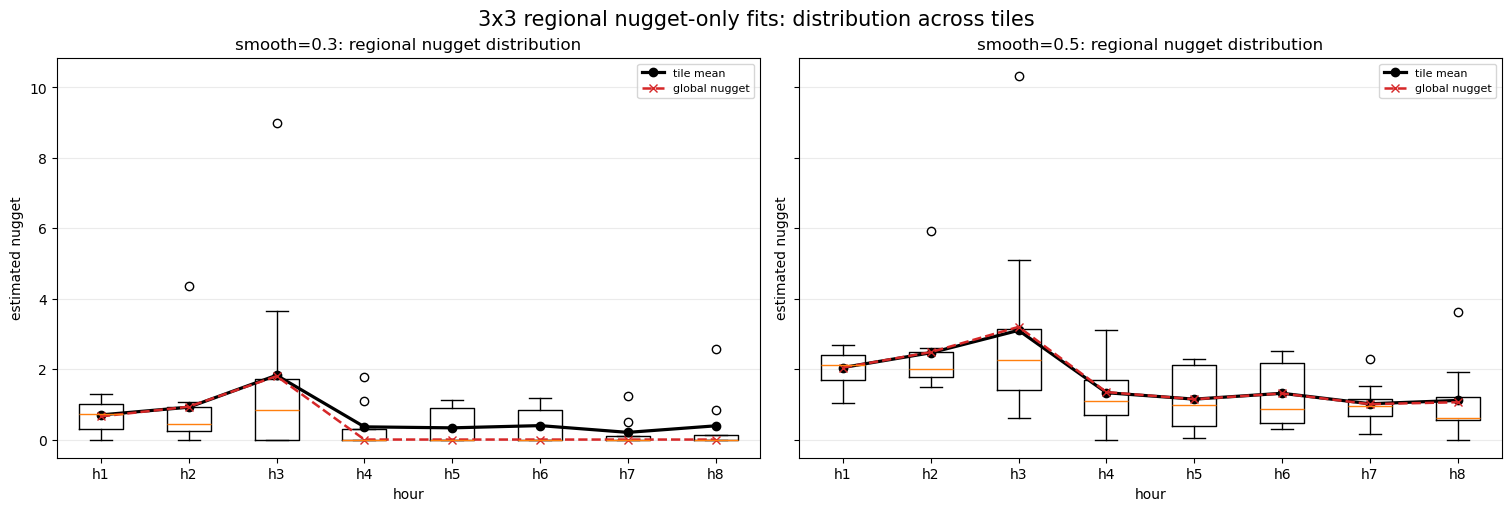

In [11]:
# Distribution plots: regional nugget by hour and smooth.
fig, axes = plt.subplots(1, len(FIT_SMOOTHS), figsize=(15, 5), constrained_layout=True, sharey=True)
if len(FIT_SMOOTHS) == 1:
    axes = [axes]

for ax, smooth in zip(axes, FIT_SMOOTHS):
    sub = ok_tile[ok_tile['smooth'] == smooth].copy()
    data = [sub[sub['hour_idx'] == h]['est_nugget'].dropna().to_numpy() for h in HOUR_IDX_LIST]
    ax.boxplot(data, labels=[f'h{h+1}' for h in HOUR_IDX_LIST], showfliers=True)
    hs = hour_summary[hour_summary['smooth'] == smooth].sort_values('hour_idx')
    ax.plot(np.arange(1, len(hs) + 1), hs['nugget_mean'], color='black', marker='o', linewidth=2.3, label='tile mean')
    ax.plot(np.arange(1, len(hs) + 1), hs['global_nugget'], color='tab:red', marker='x', linestyle='--', linewidth=1.8, label='global nugget')
    ax.set_title(f'smooth={smooth}: regional nugget distribution')
    ax.set_xlabel('hour')
    ax.set_ylabel('estimated nugget')
    ax.grid(True, axis='y', alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle('3x3 regional nugget-only fits: distribution across tiles', fontsize=15)
dist_plot_path = OUT_DIR / f'{OUT_PREFIX}_nugget_distribution_by_hour.png'
fig.savefig(dist_plot_path, dpi=180, bbox_inches='tight')
print('Saved distribution plot:', dist_plot_path)
plt.show()


Saved tile heatmap: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_tile_nugget_profile_hybrid_latmean3x3_050826_nugget_tile_heatmap_houravg.png


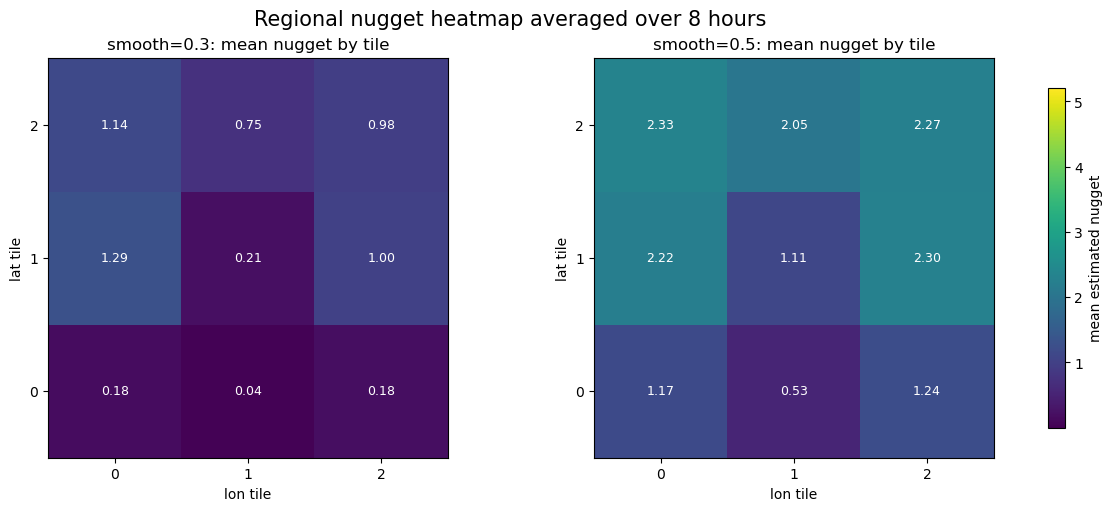

In [12]:
# Tile heatmaps averaged over hours for each smooth.
fig, axes = plt.subplots(1, len(FIT_SMOOTHS), figsize=(12, 5), constrained_layout=True)
if len(FIT_SMOOTHS) == 1:
    axes = [axes]

vmin = float(np.nanpercentile(ok_tile['est_nugget'], 2)) if len(ok_tile) else 0.0
vmax = float(np.nanpercentile(ok_tile['est_nugget'], 98)) if len(ok_tile) else 1.0

for ax, smooth in zip(axes, FIT_SMOOTHS):
    sub = ok_tile[ok_tile['smooth'] == smooth].copy()
    heat = np.full((N_TILE_ROW, N_TILE_COL), np.nan)
    for (tr, tc), g in sub.groupby(['tile_row', 'tile_col']):
        heat[int(tr), int(tc)] = g['est_nugget'].mean()
    im = ax.imshow(heat, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    for tr in range(N_TILE_ROW):
        for tc in range(N_TILE_COL):
            val = heat[tr, tc]
            if np.isfinite(val):
                ax.text(tc, tr, f'{val:.2f}', ha='center', va='center', color='white', fontsize=9)
    ax.set_title(f'smooth={smooth}: mean nugget by tile')
    ax.set_xlabel('lon tile')
    ax.set_ylabel('lat tile')
    ax.set_xticks(range(N_TILE_COL))
    ax.set_yticks(range(N_TILE_ROW))

fig.colorbar(im, ax=axes, shrink=0.85, label='mean estimated nugget')
fig.suptitle('Regional nugget heatmap averaged over 8 hours', fontsize=15)
heatmap_path = OUT_DIR / f'{OUT_PREFIX}_nugget_tile_heatmap_houravg.png'
fig.savefig(heatmap_path, dpi=180, bbox_inches='tight')
print('Saved tile heatmap:', heatmap_path)
plt.show()


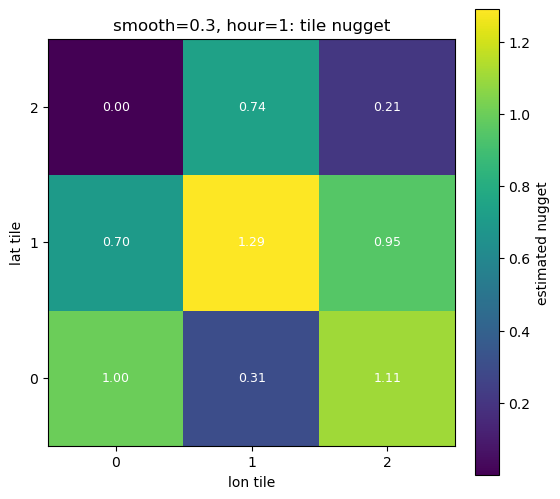

In [13]:
# Optional: inspect one hour's 3x3 nugget field.
INSPECT_SMOOTH = FIT_SMOOTHS[0]
INSPECT_HOUR_IDX = HOUR_IDX_LIST[0]

sub = ok_tile[(ok_tile['smooth'] == INSPECT_SMOOTH) & (ok_tile['hour_idx'] == INSPECT_HOUR_IDX)]
heat = np.full((N_TILE_ROW, N_TILE_COL), np.nan)
for _, r in sub.iterrows():
    heat[int(r['tile_row']), int(r['tile_col'])] = float(r['est_nugget'])

fig, ax = plt.subplots(figsize=(5.5, 5), constrained_layout=True)
im = ax.imshow(heat, origin='lower', cmap='viridis')
for tr in range(N_TILE_ROW):
    for tc in range(N_TILE_COL):
        val = heat[tr, tc]
        if np.isfinite(val):
            ax.text(tc, tr, f'{val:.2f}', ha='center', va='center', color='white', fontsize=9)
ax.set_title(f'smooth={INSPECT_SMOOTH}, hour={INSPECT_HOUR_IDX + 1}: tile nugget')
ax.set_xlabel('lon tile')
ax.set_ylabel('lat tile')
ax.set_xticks(range(N_TILE_COL))
ax.set_yticks(range(N_TILE_ROW))
fig.colorbar(im, ax=ax, label='estimated nugget')
plt.show()
